In [1]:
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training
import torch
import cv2
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

/home/pj00/anaconda3/envs/CVenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load model and tracker

In [2]:
# set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Current device: {}'.format(device))

Current device: cuda:0


In [3]:
mtcnn = MTCNN(
    image_size=160,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=True,
    device=device
)

In [4]:
tracker = cv2.TrackerKCF_create()

## Functions

In [5]:
def convert_errode(frame):
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(frame_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 21, 10)
    frame_erode = cv2.erode(thresh, np.ones(ksize, np.uint8))
    return frame_erode

## Start recording

In [6]:
ksize = (5, 5)
frame_count = 0
red    = (0, 0, 255)
yellow = (0, 255, 255)
green  = (0, 255, 0)

cap = cv2.VideoCapture(0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(width, height)

640 480


[ WARN:0@0.672] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


In [ ]:
errors = []
images = []
current_max = 0
error_thres = 0.8
while True:
    ret, frame = cap.read()
    
    if not frame_count:
        frame_erode = convert_errode(frame)
        frame_count += 1
    
    else:
        frame_erode = convert_errode(frame)
#         error = np.mean(np.square((frame_erode/255) - (prev_frame/255)))
        error = ssim(frame_erode, prev_frame)
        
        cv2.imshow('Contours', frame_erode)
        errors.append(error)
        if error_thres > error:
            images.append((frame_erode, frame))
        # Exit if ESC pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    prev_frame = frame_erode
    # Exit if ESC pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
        
cv2.waitKey(0)
cv2.destroyAllWindows()

libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


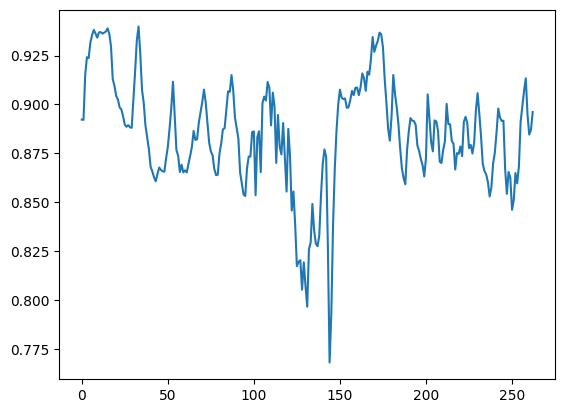

In [8]:
plt.plot(errors)

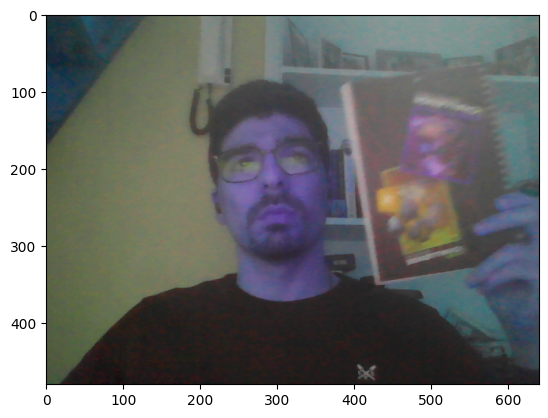

In [16]:
plt.imshow(images[4][1])

In [11]:
len(images)

27